**Clasificación de Documentos (Self-Training)**

Clasificación de correos electrónicos donde solo tenemos unos pocos ejemplos etiquetados como "Spam" o "Deseado".

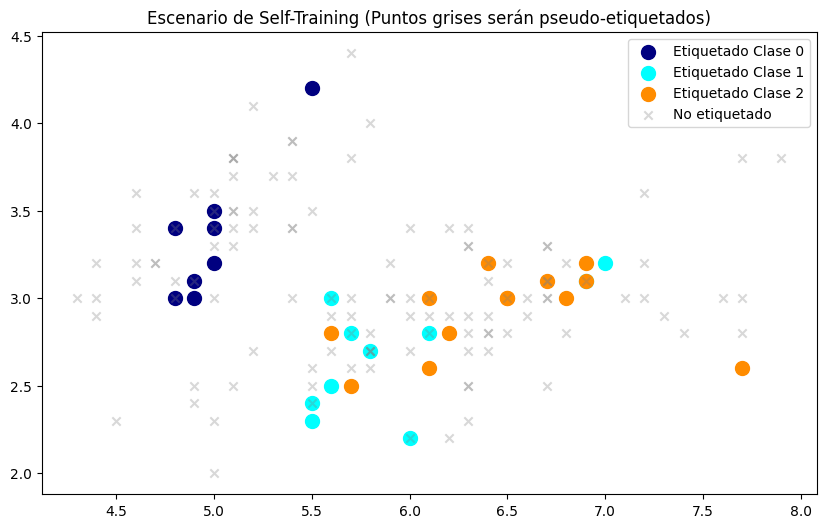

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

def caso_self_training():
    """
    Demuestra el uso de Self-Training para expandir un dataset pequeño.
    """
    # 1. Cargar datos (Iris como ejemplo pedagógico de dimensiones)
    iris = datasets.load_iris() # carga "Iris flower dataset"
    X, y = iris.data[:, :2], iris.target  #Separa dataset en datos predictores (X) y objetivo (y)

    # 2. "Ocultar" el 80% de las etiquetas (Simulando falta de datos)
    rng = np.random.RandomState(42)
    random_unlabeled_points = rng.rand(y.shape[0]) < 0.8
    y_unlabeled = np.copy(y)
    y_unlabeled[random_unlabeled_points] = -1  # -1 indica 'sin etiqueta' en sklearn

    # 3. Definir clasificador base y el wrapper Semi-Supervisado
    svc = SVC(probability=True, gamma="auto")
    self_training_model = SelfTrainingClassifier(svc)
    self_training_model.fit(X, y_unlabeled)

    # 4. Visualización
    plt.figure(figsize=(10, 6))
    colors = ['navy', 'cyan', 'darkorange']
    for i, color in zip([0, 1, 2], colors):
        mask = y_unlabeled == i
        plt.scatter(X[mask, 0], X[mask, 1], c=color, marker='o', s=100, label=f'Etiquetado Clase {i}')

    unlabeled_mask = y_unlabeled == -1
    plt.scatter(X[unlabeled_mask, 0], X[unlabeled_mask, 1], c='gray', marker='x', alpha=0.3, label='No etiquetado')

    plt.title("Escenario de Self-Training (Puntos grises serán pseudo-etiquetados)")
    plt.legend()
    plt.show()

caso_self_training()


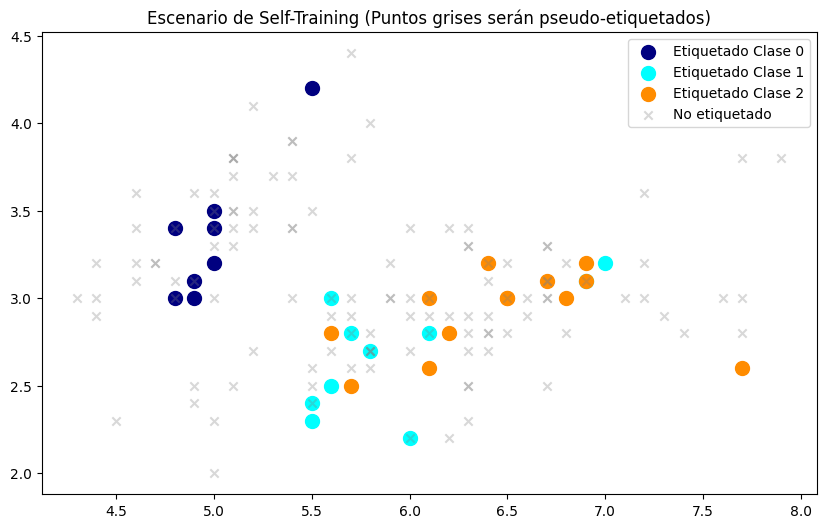

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

def caso_self_training():
    """
    Demuestra el uso de Self-Training para expandir un dataset pequeño.
    """
    # 1. Cargar datos (Iris como ejemplo pedagógico de dimensiones)
    iris = datasets.load_iris() # carga "Iris flower dataset"
    X, y = iris.data[:, :2], iris.target  #Separa dataset en datos predictores (X) y objetivo (y)

    # 2. "Ocultar" el 80% de las etiquetas (Simulando falta de datos):
    #Generacion de datos No Eqtiquetados
    rng = np.random.RandomState(42)
    '''
    rng.rand(y.shape[0]): creates an array of random numbers between 0 and 1. The size of this array is the same as the number of samples in your y (target) dataset.
    <0.8: selects about 80% of your data points to be marked as 'unlabeled'.
    '''
    random_unlabeled_points = rng.rand(y.shape[0]) < 0.8
    y_unlabeled = np.copy(y)  # genera una copia del y(target) original
    y_unlabeled[random_unlabeled_points] = -1  # -1 indica 'sin etiqueta' en sklearn

    # 3. Definir clasificador base y el wrapper Semi-Supervisado
    svc = SVC(probability=True, gamma="auto") # usa Support Vector Classifier (SVC), usa kernel RBF
    self_training_model = SelfTrainingClassifier(svc)
    self_training_model.fit(X, y_unlabeled)

    # 4. Visualización
    plt.figure(figsize=(10, 6))
    colors = ['navy', 'cyan', 'darkorange']
    for i, color in zip([0, 1, 2], colors):
        mask = y_unlabeled == i
        plt.scatter(X[mask, 0], X[mask, 1], c=color, marker='o', s=100, label=f'Etiquetado Clase {i}')

    unlabeled_mask = y_unlabeled == -1
    plt.scatter(X[unlabeled_mask, 0], X[unlabeled_mask, 1], c='gray', marker='x', alpha=0.3, label='No etiquetado')

    plt.title("Escenario de Self-Training (Puntos grises serán pseudo-etiquetados)")
    plt.legend()
    plt.show()

caso_self_training()
